In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score

df=pd.read_csv("bank-full.csv",sep=";")
print(df.head)

<bound method NDFrame.head of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day

In [17]:
print(df.tail)
print(df.describe)
print(df.isnull)
print(df.info())

<bound method NDFrame.tail of        age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day

In [18]:
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [19]:
print(df.columns.tolist())
le=LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col]=le.fit_transform(df[col])
x=df.drop("y",axis=1)
y=df["y"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
gini=DecisionTreeClassifier(criterion="gini",random_state=42)
gini.fit(x_train,y_train)
pred_gini=gini.predict(x_test)
print("\nAccuracy (Gini):",round(accuracy_score(y_test,pred_gini),3))


entropy=DecisionTreeClassifier(criterion="entropy",random_state=42)
entropy.fit(x_train,y_train)
pred_entropy=entropy.predict(x_test)
print("\nAccuracy (entropy):",round(accuracy_score(y_test,pred_entropy),3))

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Accuracy (Gini): 0.874

Accuracy (entropy): 0.876



Decision Rule 1:
If the customer has suitable contract and campaign details,the customer may subscribe .

Decision Rule 2:
If the customer has no suitable contract and campaign details,the customer may not subscribe.


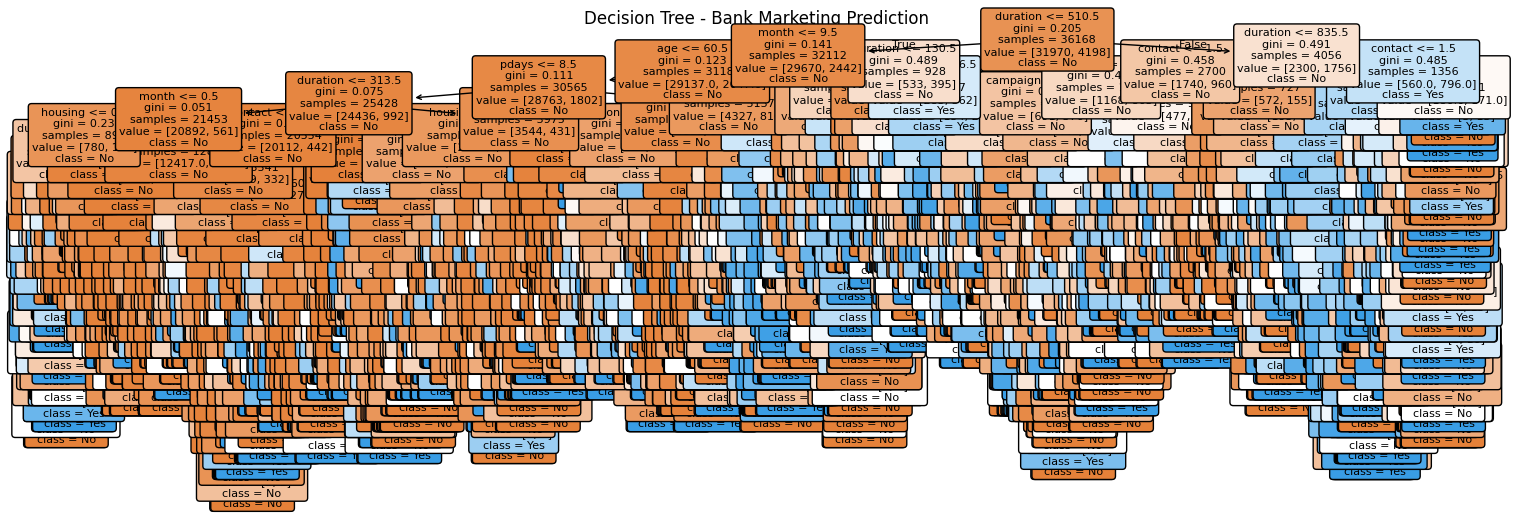

In [20]:
plt.figure(figsize=(18,6))
plot_tree(gini,feature_names=x.columns,class_names=['No','Yes'],filled=True,rounded=True,fontsize=8)
plt.title("Decision Tree - Bank Marketing Prediction")
print("\nDecision Rule 1:")
print("If the customer has suitable contract and campaign details,the customer may subscribe .")
print("\nDecision Rule 2:")
print("If the customer has no suitable contract and campaign details,the customer may not subscribe.")


Depth Comparison
-----------------------
Depth=   1 Train=0.884 Test=0.879
Depth=   2 Train=0.890 Test=0.885
Depth=   3 Train=0.893 Test=0.886
Depth=   4 Train=0.895 Test=0.888
Depth=   5 Train=0.901 Test=0.894
Depth=   6 Train=0.906 Test=0.895
Depth=None Train=1.000 Test=0.874


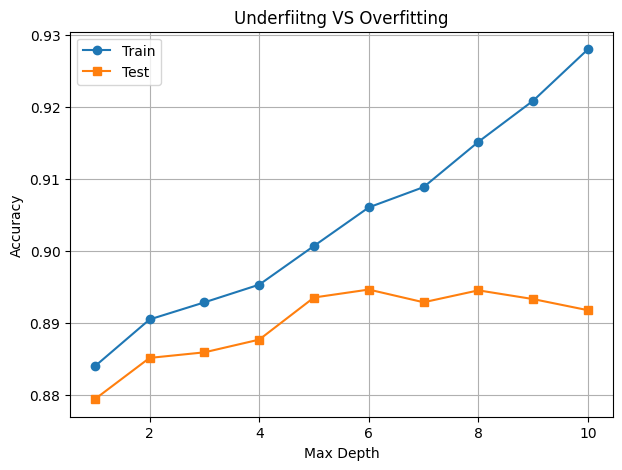


 Interpretation
----------------------
Small depth -> Underfitting
Very large depth -> Overfitting
Best depth where the test accuracy is highest.


In [21]:
print("\nDepth Comparison")
print("-----------------------")
for depth in [1,2,3,4,5,6,None]:
    model=DecisionTreeClassifier(max_depth=depth,criterion='gini',random_state=42)
    model.fit(x_train,y_train)
    train_acc=accuracy_score(y_train,model.predict(x_train))
    test_acc=accuracy_score(y_test,model.predict(x_test))
    print(f"Depth={str(depth):>4} Train={train_acc:.3f} Test={test_acc:.3f}")
train_scores=[]
test_scores=[]
for d in range(1,11):
    model=DecisionTreeClassifier(max_depth=d,random_state=42)
    model.fit(x_train,y_train)
    train_scores.append(accuracy_score(y_train,model.predict(x_train)))
    test_scores.append(accuracy_score(y_test,model.predict(x_test)))
plt.figure(figsize=(7,5))
plt.plot(range(1,11),train_scores,marker='o',label="Train")
plt.plot(range(1,11),test_scores,marker='s',label="Test")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Underfiitng VS Overfitting")
plt.legend()
plt.grid(True)
plt.show()

print("\n Interpretation")
print("----------------------")
print("Small depth -> Underfitting")
print("Very large depth -> Overfitting")
print("Best depth where the test accuracy is highest.")
